In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS (consistent style)
# -----------------------------

beta_star = 0.08      # growth coefficient (1/(light * nutrient * hr))
mu = 0.00625          # mortality rate (1/hr)

Pa = 0.5              # nutrient released per death
Pb = 0.5              # nutrient uptake factor

T_end = 72            # simulate 3 days (hours)
dt = 0.1
t = np.arange(0, T_end, dt)

# -----------------------------
# LIGHT FUNCTION (day/night)
# -----------------------------
def light_intensity(t):
    t_mod = t % 24
    if 0 <= t_mod <= 12:
        return np.sin(np.pi * t_mod / 12)
    else:
        return 0.0

# Vectorize for plotting
I_vals = np.array([light_intensity(tt) for tt in t])

# -----------------------------
# INITIAL CONDITIONS
# -----------------------------
NL0 = 0.5     # live algae
ND0 = 0.0     # dead algae
P0  = 1.0     # nutrient concentration

# Arrays
NL = np.zeros_like(t)
ND = np.zeros_like(t)
P  = np.zeros_like(t)

NL[0] = NL0
ND[0] = ND0
P[0]  = P0

# -----------------------------
# RK4 SOLVER
# -----------------------------
def derivatives(NL, ND, P, t):
    I = light_intensity(t)
   
    dNLdt = beta_star * I * P * NL - mu * NL
    dNDdt = mu * NL
    dPdt  = Pa * mu * NL - Pb * beta_star * I * P * NL
   
    return dNLdt, dNDdt, dPdt

for i in range(len(t)-1):
    ti = t[i]
   
    k1_NL, k1_ND, k1_P = derivatives(NL[i], ND[i], P[i], ti)
   
    k2_NL, k2_ND, k2_P = derivatives(
        NL[i] + 0.5*dt*k1_NL,
        ND[i] + 0.5*dt*k1_ND,
        P[i]  + 0.5*dt*k1_P,
        ti + 0.5*dt
    )
   
    k3_NL, k3_ND, k3_P = derivatives(
        NL[i] + 0.5*dt*k2_NL,
        ND[i] + 0.5*dt*k2_ND,
        P[i]  + 0.5*dt*k2_P,
        ti + 0.5*dt
    )
   
    k4_NL, k4_ND, k4_P = derivatives(
        NL[i] + dt*k3_NL,
        ND[i] + dt*k3_ND,
        P[i]  + dt*k3_P,
        ti + dt
    )
   
    NL[i+1] = NL[i] + (dt/6)*(k1_NL + 2*k2_NL + 2*k3_NL + k4_NL)
    ND[i+1] = ND[i] + (dt/6)*(k1_ND + 2*k2_ND + 2*k3_ND + k4_ND)
    P[i+1]  = P[i]  + (dt/6)*(k1_P  + 2*k2_P  + 2*k3_P  + k4_P)

# -----------------------------
# PLOTTING
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(t, NL, label="Live Algae", linewidth=2)
plt.plot(t, ND, label="Dead Algae", linewidth=2)
plt.plot(t, P, label="Nutrients", linewidth=2)
plt.plot(t, I_vals, label="Light Intensity", linestyle='--')

plt.xlabel("Time (hours)")
plt.ylabel("Concentration / Intensity")
plt.title("Algal Dynamics with Nutrient Feedback")
plt.legend()
plt.grid()

plt.show()





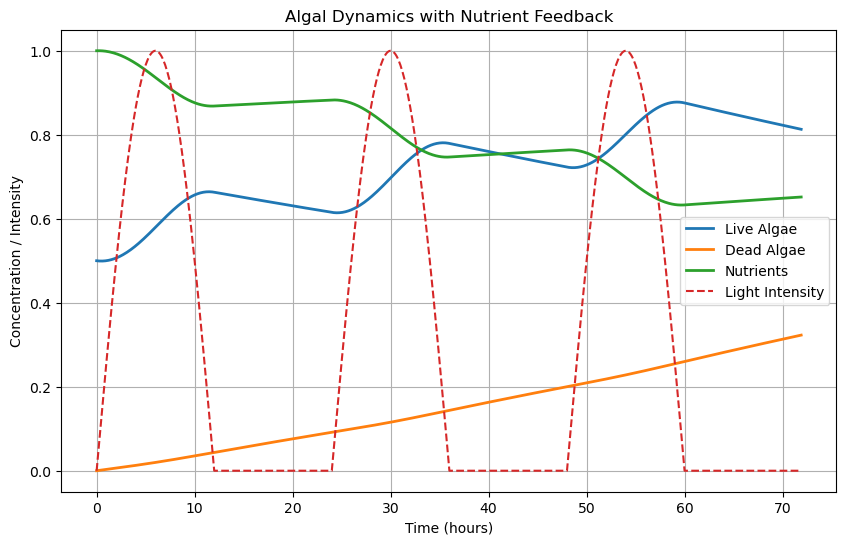

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS (consistent style)
# -----------------------------
Pa = 0.3
Pb = 0.7
beta_star = 0.05



#beta_star = 0.08      # growth coefficient (1/(light * nutrient * hr))
mu = 0.00625          # mortality rate (1/hr)

#Pa = 0.5              # nutrient released per death
#Pb = 0.5              # nutrient uptake factor

T_end = 72            # simulate 3 days (hours)
dt = 0.1
t = np.arange(0, T_end, dt)

# -----------------------------
# LIGHT FUNCTION (day/night)
# -----------------------------
def light_intensity(t):
    t_mod = t % 24
    if 0 <= t_mod <= 12:
        return np.sin(np.pi * t_mod / 12)
    else:
        return 0.0

# Vectorize for plotting
I_vals = np.array([light_intensity(tt) for tt in t])

# -----------------------------
# INITIAL CONDITIONS
# -----------------------------
NL0 = 0.5     # live algae
ND0 = 0.0     # dead algae
P0  = 1.0     # nutrient concentration

# Arrays
NL = np.zeros_like(t)
ND = np.zeros_like(t)
P  = np.zeros_like(t)

NL[0] = NL0
ND[0] = ND0
P[0]  = P0

# -----------------------------
# RK4 SOLVER
# -----------------------------
def derivatives(NL, ND, P, t):
    I = light_intensity(t)
   
    dNLdt = beta_star * I * P * NL - mu * NL
    dNDdt = mu * NL
    dPdt  = Pa * mu * NL - Pb * beta_star * I * P * NL
   
    return dNLdt, dNDdt, dPdt

for i in range(len(t)-1):
    ti = t[i]
   
    k1_NL, k1_ND, k1_P = derivatives(NL[i], ND[i], P[i], ti)
   
    k2_NL, k2_ND, k2_P = derivatives(
        NL[i] + 0.5*dt*k1_NL,
        ND[i] + 0.5*dt*k1_ND,
        P[i]  + 0.5*dt*k1_P,
        ti + 0.5*dt
    )
   
    k3_NL, k3_ND, k3_P = derivatives(
        NL[i] + 0.5*dt*k2_NL,
        ND[i] + 0.5*dt*k2_ND,
        P[i]  + 0.5*dt*k2_P,
        ti + 0.5*dt
    )
   
    k4_NL, k4_ND, k4_P = derivatives(
        NL[i] + dt*k3_NL,
        ND[i] + dt*k3_ND,
        P[i]  + dt*k3_P,
        ti + dt
    )
   
    NL[i+1] = NL[i] + (dt/6)*(k1_NL + 2*k2_NL + 2*k3_NL + k4_NL)
    ND[i+1] = ND[i] + (dt/6)*(k1_ND + 2*k2_ND + 2*k3_ND + k4_ND)
    P[i+1]  = P[i]  + (dt/6)*(k1_P  + 2*k2_P  + 2*k3_P  + k4_P)

# -----------------------------
# PLOTTING
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(t, NL, label="Live Algae", linewidth=2)
plt.plot(t, ND, label="Dead Algae", linewidth=2)
plt.plot(t, P, label="Nutrients", linewidth=2)
plt.plot(t, I_vals, label="Light Intensity", linestyle='--')

plt.xlabel("Time (hours)")
plt.ylabel("Concentration / Intensity")
plt.title("Algal Dynamics with Nutrient Feedback")
plt.legend()
plt.grid()

plt.show()

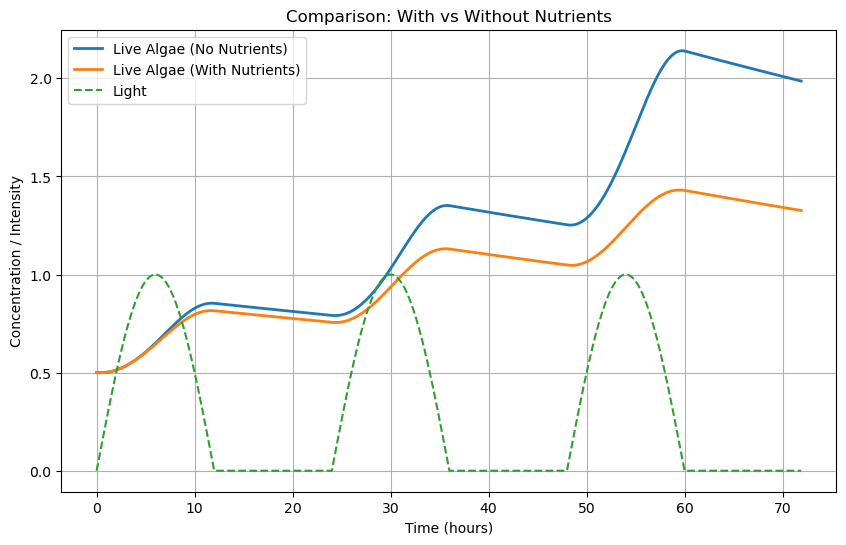

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
beta = 0.08
beta_star = 0.08
mu = 0.00625
Pa = 0.5
Pb = 0.5

#Pa=1.5
#Pb=1.5
#beta_star=0.12


T_end = 72
dt = 0.1
t = np.arange(0, T_end, dt)

# -----------------------------
# LIGHT FUNCTION
# -----------------------------
def light_intensity(t):
    t_mod = t % 24
    if 0 <= t_mod <= 12:
        return np.sin(np.pi * t_mod / 12)
    else:
        return 0.0

I_vals = np.array([light_intensity(tt) for tt in t])

# -----------------------------
# MODEL 1 (NO NUTRIENTS)
# -----------------------------
NL1 = np.zeros_like(t)
NL1[0] = 0.5

for i in range(len(t)-1):
    I = light_intensity(t[i])
    dNL = (beta * I - mu) * NL1[i]
    NL1[i+1] = NL1[i] + dt * dNL

# -----------------------------
# MODEL 2 (WITH NUTRIENTS)
# -----------------------------
NL2 = np.zeros_like(t)
P = np.zeros_like(t)

NL2[0] = 0.5
P[0] = 1.0

for i in range(len(t)-1):
    I = light_intensity(t[i])
   
    dNL = (beta_star * I * P[i] - mu) * NL2[i]
    dP  = Pa * mu * NL2[i] - Pb * beta_star * I * P[i] * NL2[i]
   
    NL2[i+1] = NL2[i] + dt * dNL
    P[i+1] = P[i] + dt * dP

# -----------------------------
# PLOT COMPARISON
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(t, NL1, label="Live Algae (No Nutrients)", linewidth=2)
plt.plot(t, NL2, label="Live Algae (With Nutrients)", linewidth=2)
plt.plot(t, I_vals, label="Light", linestyle="--")

plt.xlabel("Time (hours)")
plt.ylabel("Concentration / Intensity")
plt.title("Comparison: With vs Without Nutrients")
plt.legend()
plt.grid()

plt.show()


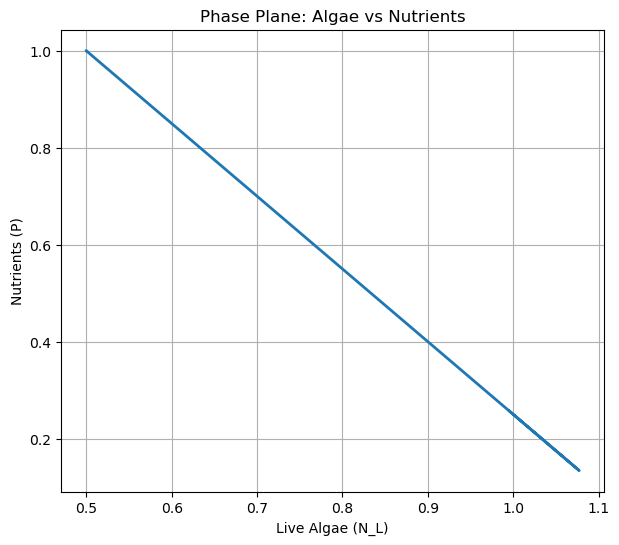

In [13]:
plt.figure(figsize=(7,6))

plt.plot(NL2, P, linewidth=2)

plt.xlabel("Live Algae (N_L)")
plt.ylabel("Nutrients (P)")
plt.title("Phase Plane: Algae vs Nutrients")
plt.grid()

plt.show()

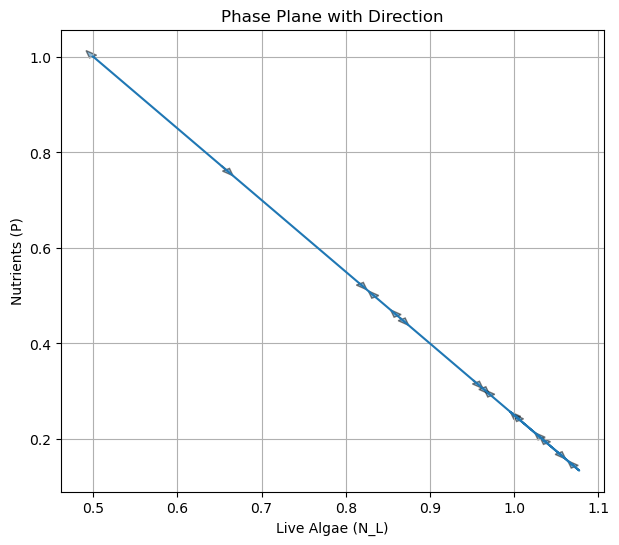

In [15]:
plt.figure(figsize=(7,6))

plt.plot(NL2, P)

for i in range(0, len(NL2), 50):
    plt.arrow(NL2[i], P[i],
              NL2[i+1]-NL2[i],
              P[i+1]-P[i],
              head_width=0.01, alpha=0.5)

plt.xlabel("Live Algae (N_L)")
plt.ylabel("Nutrients (P)")
plt.title("Phase Plane with Direction")
plt.grid()

plt.show()

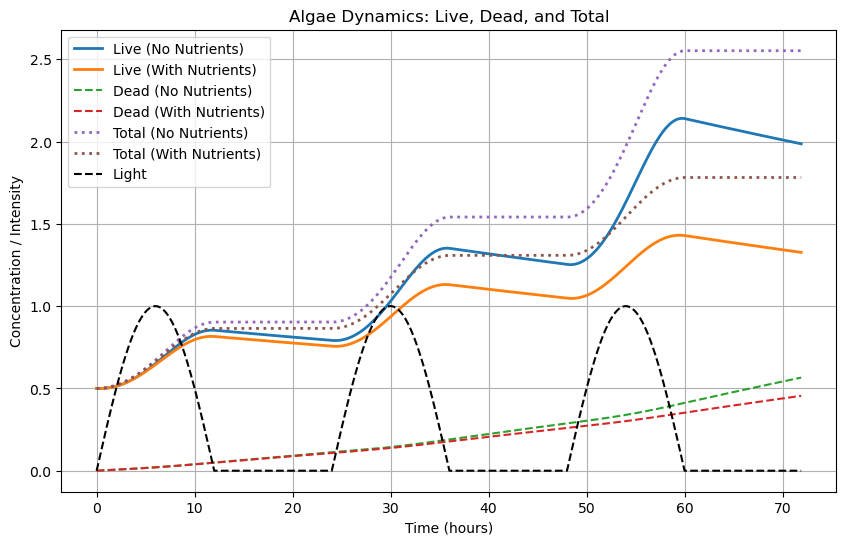

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
beta = 0.08
beta_star = 0.08
mu = 0.00625
Pa = 0.5
Pb = 0.5

T_end = 72
dt = 0.1
t = np.arange(0, T_end, dt)

# -----------------------------
# LIGHT FUNCTION
# -----------------------------
def light_intensity(t):
    t_mod = t % 24
    if 0 <= t_mod <= 12:
        return np.sin(np.pi * t_mod / 12)
    else:
        return 0.0

I_vals = np.array([light_intensity(tt) for tt in t])

# -----------------------------
# MODEL 1 (NO NUTRIENTS)
# -----------------------------
NL1 = np.zeros_like(t)
ND1 = np.zeros_like(t)

NL1[0] = 0.5
ND1[0] = 0.0

for i in range(len(t)-1):
    I = light_intensity(t[i])

    dNL = (beta * I - mu) * NL1[i]
    dND = mu * NL1[i]

    NL1[i+1] = NL1[i] + dt * dNL
    ND1[i+1] = ND1[i] + dt * dND

# -----------------------------
# MODEL 2 (WITH NUTRIENTS)
# -----------------------------
NL2 = np.zeros_like(t)
ND2 = np.zeros_like(t)
P = np.zeros_like(t)

NL2[0] = 0.5
ND2[0] = 0.0
P[0] = 1.0

for i in range(len(t)-1):
    I = light_intensity(t[i])

    dNL = (beta_star * I * P[i] - mu) * NL2[i]
    dND = mu * NL2[i]
    dP  = Pa * mu * NL2[i] - Pb * beta_star * I * P[i] * NL2[i]

    NL2[i+1] = NL2[i] + dt * dNL
    ND2[i+1] = ND2[i] + dt * dND
    P[i+1] = P[i] + dt * dP

# -----------------------------
# TOTAL ALGAE
# -----------------------------
N1 = NL1 + ND1
N2 = NL2 + ND2

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10,6))

# Live algae
plt.plot(t, NL1, label="Live (No Nutrients)", linewidth=2)
plt.plot(t, NL2, label="Live (With Nutrients)", linewidth=2)

# Dead algae
plt.plot(t, ND1, '--', label="Dead (No Nutrients)")
plt.plot(t, ND2, '--', label="Dead (With Nutrients)")

# Total algae
plt.plot(t, N1, ':', label="Total (No Nutrients)", linewidth=2)
plt.plot(t, N2, ':', label="Total (With Nutrients)", linewidth=2)

# Light
plt.plot(t, I_vals, label="Light", linestyle="--", color='black')

plt.xlabel("Time (hours)")
plt.ylabel("Concentration / Intensity")
plt.title("Algae Dynamics: Live, Dead, and Total")
plt.legend()
plt.grid()

plt.show()

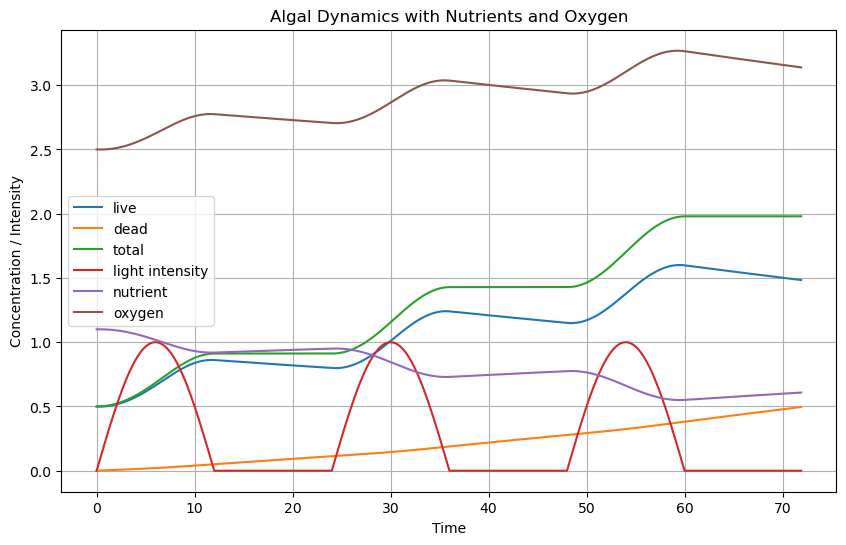

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS (tune if needed)
# -----------------------------
beta = 0.08        # growth coefficient
mu = 0.00625       # মৃত্যু (mortality)

Pa = 0.5           # nutrient release from death
Pb = 0.5           # nutrient uptake

Qa = 0.3           # oxygen consumed (decomposition)
Qb = 0.8           # oxygen produced (photosynthesis)

# -----------------------------
# TIME SETUP
# -----------------------------
T_end = 72
dt = 0.1
t = np.arange(0, T_end, dt)

# -----------------------------
# LIGHT FUNCTION (day/night cycle)
# -----------------------------
def light_intensity(t):
    t_mod = t % 24
    if 0 <= t_mod <= 12:
        return np.sin(np.pi * t_mod / 12)
    else:
        return 0.0

I_vals = np.array([light_intensity(tt) for tt in t])

# -----------------------------
# INITIAL CONDITIONS
# -----------------------------
NL = np.zeros_like(t)   # live algae
ND = np.zeros_like(t)   # dead algae
P  = np.zeros_like(t)   # nutrients
Q  = np.zeros_like(t)   # oxygen

NL[0] = 0.5
ND[0] = 0.0
P[0]  = 1.1
Q[0]  = 2.5

# -----------------------------
# TIME INTEGRATION (Euler)
# -----------------------------
for i in range(len(t)-1):
    I = light_intensity(t[i])
   
    dNL = (beta * I * P[i] - mu) * NL[i]
    dND = mu * NL[i]
    dP  = Pa * mu * NL[i] - Pb * beta * I * P[i] * NL[i]
    dQ  = -(Qa + Qb) * mu * NL[i] + Qb * beta * I * P[i] * NL[i]
   
    NL[i+1] = NL[i] + dt * dNL
    ND[i+1] = ND[i] + dt * dND
    P[i+1]  = P[i]  + dt * dP
    Q[i+1]  = Q[i]  + dt * dQ

# Total algae
N_total = NL + ND

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(t, NL, label="live")
plt.plot(t, ND, label="dead")
plt.plot(t, N_total, label="total")
plt.plot(t, I_vals, label="light intensity")
plt.plot(t, P, label="nutrient")
plt.plot(t, Q, label="oxygen")

plt.xlabel("Time")
plt.ylabel("Concentration / Intensity")
plt.title("Algal Dynamics with Nutrients and Oxygen")
plt.legend()
plt.grid()

plt.show()


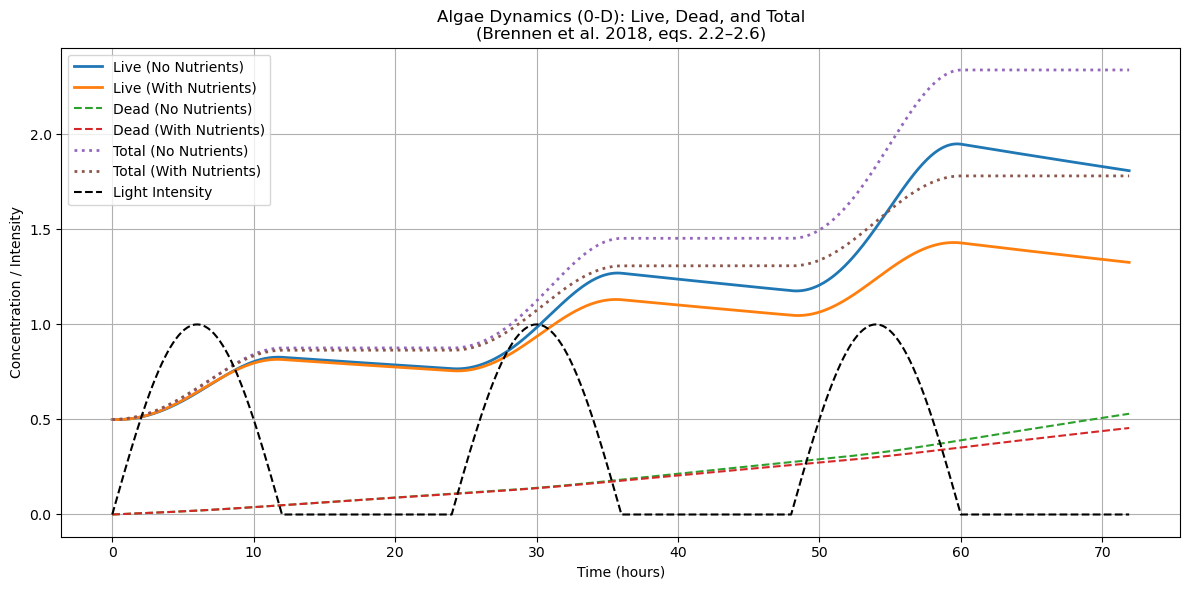

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS (from paper §5)
# -----------------------------
beta      = 0.0759    # growth rate constant, /h (paper: βI* = 0.0759/h)
beta_star = 0.08      # growth rate with nutrients, /h per nutrient unit
mu        = 0.00625   # mortality rate, /h (paper: 0.15/day = 0.00625/h)
Pa        = 0.5       # nutrient released per dead cell
Pb        = 0.5       # nutrient uptake proportionality
T_end     = 72        # hours
dt        = 0.1
t         = np.arange(0, T_end, dt)

# -----------------------------
# LIGHT FUNCTION (eq. 2.16)
# -----------------------------
def light_intensity(t_val):
    t_mod = t_val % 24
    return np.sin(np.pi * t_mod / 12) if 0 < t_mod <= 12 else 0.0

I_vals = np.array([light_intensity(tt) for tt in t])

# -----------------------------
# MODEL 1: No Nutrients (eqs. 2.2, 2.3, mp = βI)
# -----------------------------
NL1 = np.zeros_like(t)
ND1 = np.zeros_like(t)
NL1[0] = 0.5
ND1[0] = 0.0

for i in range(len(t) - 1):
    I = light_intensity(t[i])
    dNL = (beta * I - mu) * NL1[i]
    dND = mu * NL1[i]
    NL1[i+1] = NL1[i] + dt * dNL
    ND1[i+1] = ND1[i] + dt * dND
    NL1[i+1] = max(NL1[i+1], 0.0)  # physical floor

# -----------------------------
# MODEL 2: With Nutrients (eqs. 2.5, 2.6, mp = β*IP)
# -----------------------------
NL2 = np.zeros_like(t)
ND2 = np.zeros_like(t)
P   = np.zeros_like(t)
NL2[0] = 0.5
ND2[0] = 0.0
P[0]   = 1.0

for i in range(len(t) - 1):
    I = light_intensity(t[i])
    dNL = (beta_star * I * P[i] - mu) * NL2[i]
    dND = mu * NL2[i]
    dP  = Pa * mu * NL2[i] - Pb * beta_star * I * P[i] * NL2[i]
    NL2[i+1] = max(NL2[i] + dt * dNL, 0.0)
    ND2[i+1] = ND2[i] + dt * dND
    P[i+1]   = max(P[i] + dt * dP, 0.0)   # nutrient can't go negative

# -----------------------------
# TOTAL ALGAE
# -----------------------------
N1 = NL1 + ND1
N2 = NL2 + ND2

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(t, NL1, label="Live (No Nutrients)",    linewidth=2)
plt.plot(t, NL2, label="Live (With Nutrients)",  linewidth=2)
plt.plot(t, ND1, '--', label="Dead (No Nutrients)")
plt.plot(t, ND2, '--', label="Dead (With Nutrients)")
plt.plot(t, N1,  ':',  label="Total (No Nutrients)", linewidth=2)
plt.plot(t, N2,  ':',  label="Total (With Nutrients)", linewidth=2)
plt.plot(t, I_vals, '--', color='black', label="Light Intensity")

plt.xlabel("Time (hours)")
plt.ylabel("Concentration / Intensity")
plt.title("Algae Dynamics (0-D): Live, Dead, and Total\n(Brennen et al. 2018, eqs. 2.2–2.6)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

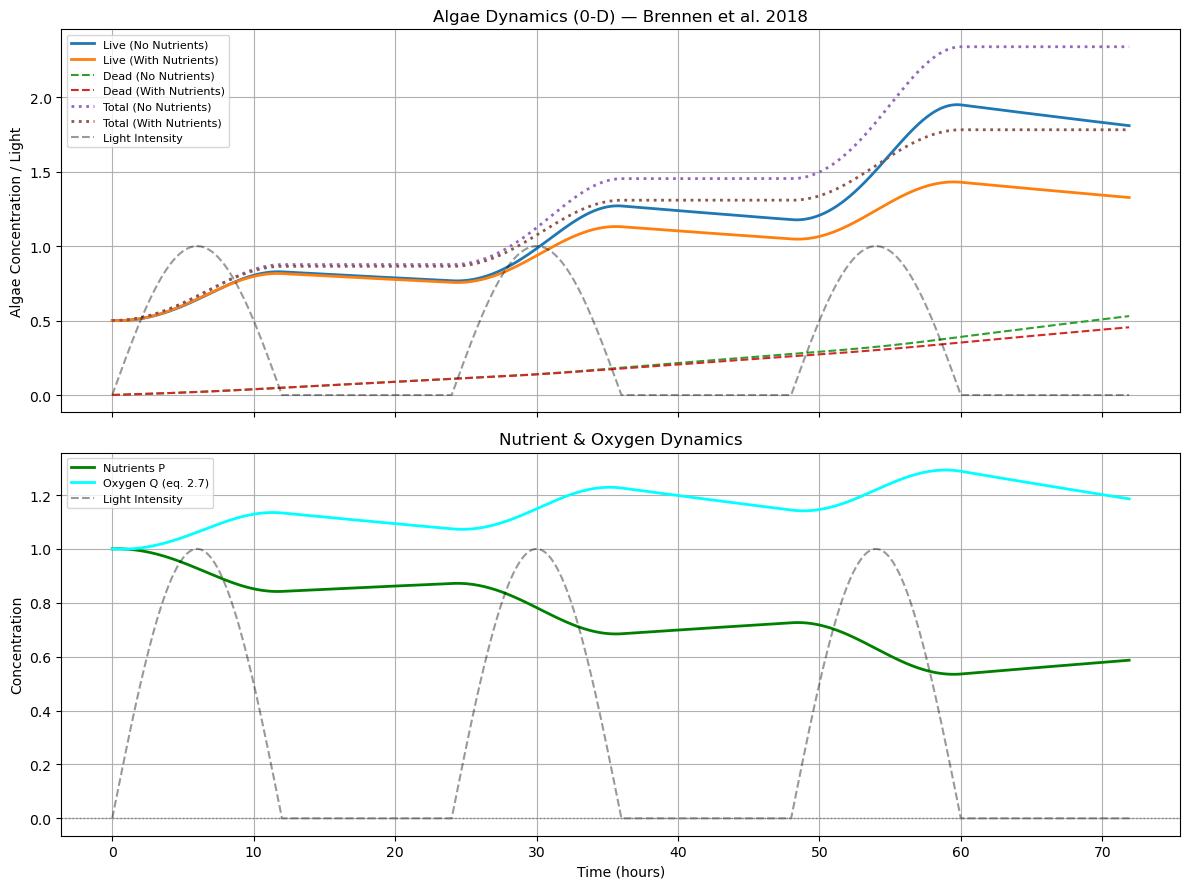

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS (from paper §5)
# -----------------------------
beta      = 0.0759
beta_star = 0.08
mu        = 0.00625
Pa        = 0.5
Pb        = 0.5
Qa        = 0.5   # oxygen consumed per dead cell decomposing
Qb        = 0.5    # oxygen produced per cell via photosynthesis
T_end     = 72
dt        = 0.1
t         = np.arange(0, T_end, dt)

# -----------------------------
# LIGHT FUNCTION (eq. 2.16)
# -----------------------------
def light_intensity(t_val):
    t_mod = t_val % 24
    return np.sin(np.pi * t_mod / 12) if 0 < t_mod <= 12 else 0.0

I_vals = np.array([light_intensity(tt) for tt in t])

# -----------------------------
# MODEL 1: No Nutrients (eqs. 2.2, 2.3)
# -----------------------------
NL1 = np.zeros_like(t)
ND1 = np.zeros_like(t)
NL1[0] = 0.5
ND1[0] = 0.0

for i in range(len(t) - 1):
    I = light_intensity(t[i])
    dNL = (beta * I - mu) * NL1[i]
    dND = mu * NL1[i]
    NL1[i+1] = max(NL1[i] + dt * dNL, 0.0)
    ND1[i+1] = ND1[i] + dt * dND

# -----------------------------
# MODEL 2: With Nutrients + Oxygen (eqs. 2.5, 2.6, 2.7)
# -----------------------------
NL2 = np.zeros_like(t)
ND2 = np.zeros_like(t)
P   = np.zeros_like(t)
Q   = np.zeros_like(t)
NL2[0] = 0.5
ND2[0] = 0.0
P[0]   = 1.0
Q[0]   = 1.0    # reference oxygen concentration

for i in range(len(t) - 1):
    I = light_intensity(t[i])
    dNL = (beta_star * I * P[i] - mu) * NL2[i]
    dND = mu * NL2[i]
    dP  = Pa * mu * NL2[i] - Pb * beta_star * I * P[i] * NL2[i]
    # eq. 2.7: oxygen consumed by decomposition, produced by photosynthesis
    dQ  = -(Qa + Qb) * mu * NL2[i] + Qb * beta_star * I * P[i] * NL2[i]
    NL2[i+1] = max(NL2[i] + dt * dNL, 0.0)
    ND2[i+1] = ND2[i] + dt * dND
    P[i+1]   = max(P[i]  + dt * dP,  0.0)
    Q[i+1]   =     Q[i]  + dt * dQ         # oxygen can go negative (hypoxia)

N1 = NL1 + ND1
N2 = NL2 + ND2

# -----------------------------
# PLOT — two subplots to keep oxygen scale separate
# -----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Top: Algae + Light ---
ax1.plot(t, NL1, label="Live (No Nutrients)",      linewidth=2)
ax1.plot(t, NL2, label="Live (With Nutrients)",    linewidth=2)
ax1.plot(t, ND1, '--', label="Dead (No Nutrients)")
ax1.plot(t, ND2, '--', label="Dead (With Nutrients)")
ax1.plot(t, N1,  ':',  label="Total (No Nutrients)",   linewidth=2)
ax1.plot(t, N2,  ':',  label="Total (With Nutrients)", linewidth=2)
ax1.plot(t, I_vals, '--', color='black', alpha=0.4, label="Light Intensity")
ax1.set_ylabel("Algae Concentration / Light")
ax1.set_title("Algae Dynamics (0-D) — Brennen et al. 2018")
ax1.legend(fontsize=8)
ax1.grid(True)

# --- Bottom: Nutrients + Oxygen ---
ax2.plot(t, P, color='green',  linewidth=2, label="Nutrients P")
ax2.plot(t, Q, color='cyan',   linewidth=2, label="Oxygen Q (eq. 2.7)")
ax2.plot(t, I_vals, '--', color='black', alpha=0.4, label="Light Intensity")
ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
ax2.set_xlabel("Time (hours)")
ax2.set_ylabel("Concentration")
ax2.set_title("Nutrient & Oxygen Dynamics")
ax2.legend(fontsize=8)
ax2.grid(True)

plt.tight_layout()
plt.show()